# Build Branded Business Artifacts in 6 Steps

**A CompleteTech LLC walkthrough — `agentic_contract_skill`**

This notebook teaches you how to turn a single INI file into three production-grade PDFs:

1. A multi-page **Agentic Development Services Agreement** (contract).
2. A printable **#10 addressed envelope** for mailing the contract.
3. A landscape **Certificate of Attendance** for course attendees.

Everything is driven from `config.ini`. You change the data; the generators handle the formatting, branding, signature, and seal.

---

## Prerequisites

- Python 3.10+
- Run from the project root (the folder containing `generate_contract.py`).
- Install runtime dependencies:
  ```bash
  pip install -r requirements.txt
  ```
- For inline PDF previews in this notebook, also install **PyMuPDF**:
  ```bash
  pip install pymupdf
  ```
  (If PyMuPDF isn't installed, the preview cells will print file paths instead of rendering — generation still works.)

### Notebook helpers

Two small helpers we'll reuse throughout: `run(...)` invokes the generators as a real subprocess (so what you copy-paste into a terminal works identically), and `show_pdf(...)` renders a PDF page inline.

In [1]:
import subprocess
import sys
from pathlib import Path
from IPython.display import Image, display, Markdown

PROJECT_ROOT = Path.cwd()
PREVIEW_DIR = PROJECT_ROOT / "preview"
PREVIEW_DIR.mkdir(exist_ok=True)

def run(*args: str) -> None:
    """Run a subprocess command, stream its output, and raise on nonzero exit."""
    print("$", " ".join(str(a) for a in args))
    result = subprocess.run([str(a) for a in args], cwd=PROJECT_ROOT,
                            capture_output=True, text=True)
    if result.stdout:
        print(result.stdout, end="")
    if result.returncode != 0:
        print(result.stderr, end="", file=sys.stderr)
        raise RuntimeError(f"Command exited {result.returncode}")

def show_pdf(pdf_path: str, page: int = 0, dpi: int = 110, width: int = 900) -> None:
    """Render one page of a PDF and display it inline. Falls back to a path link
    if PyMuPDF isn't installed."""
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        print(f"(missing) {pdf_path}")
        return
    try:
        import fitz  # PyMuPDF
    except ImportError:
        display(Markdown(f"_PyMuPDF not installed — PDF saved at `{pdf_path}`._"))
        return
    out_png = PREVIEW_DIR / f"{pdf_path.stem}_page-{page+1}.png"
    fitz.open(pdf_path)[page].get_pixmap(dpi=dpi).save(out_png)
    display(Image(filename=str(out_png), width=width))


### What we'll build

If you've already run the generators once, the project ships with previews you can peek at now to set expectations:

**contract_page-1.png**

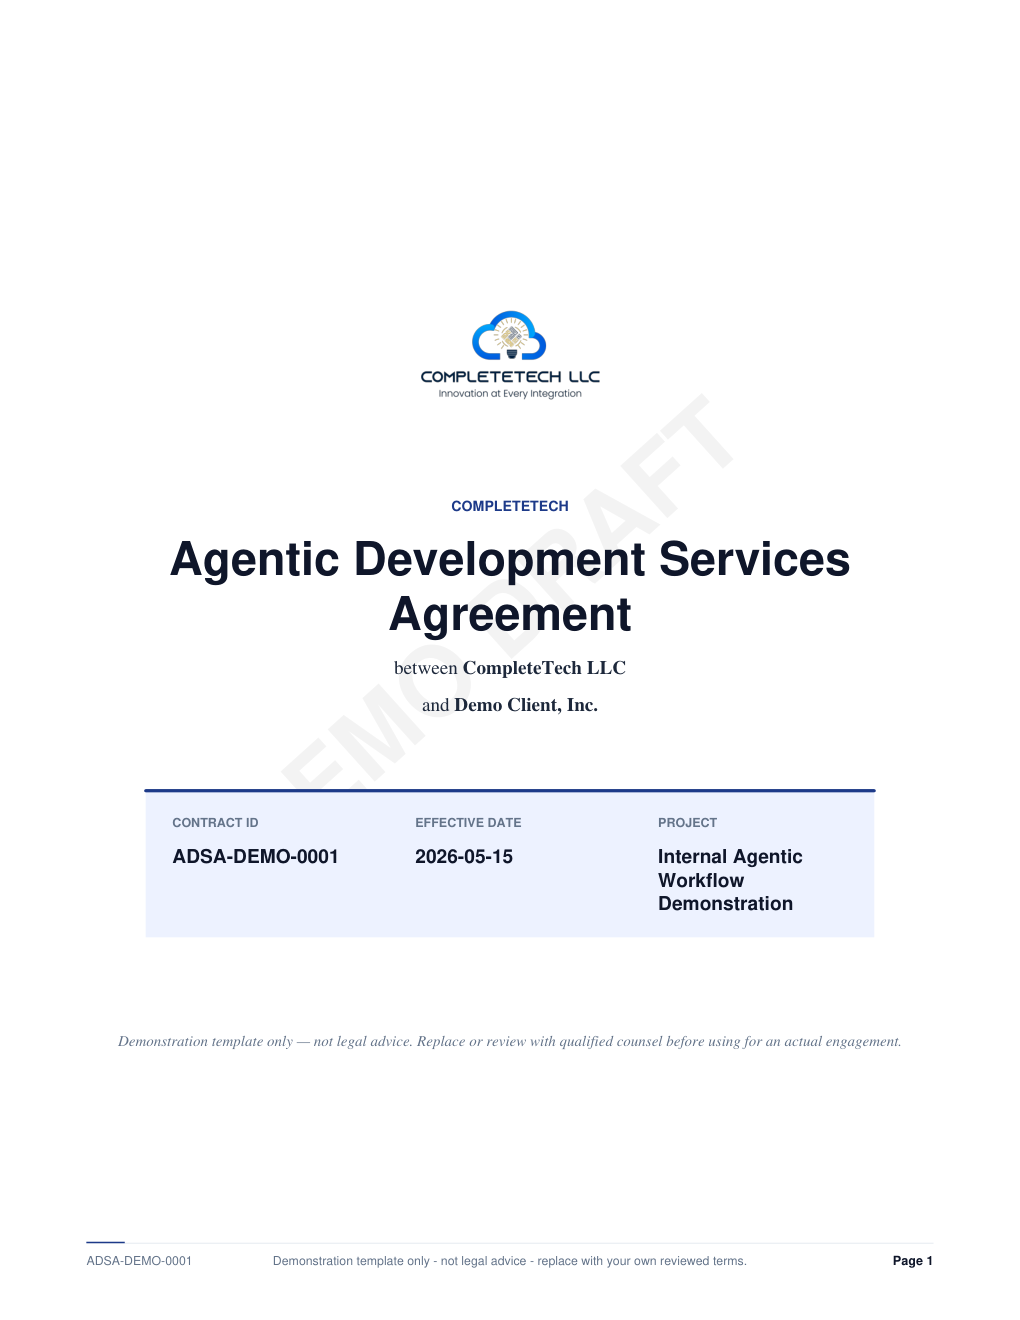

**envelope_page-1.png**

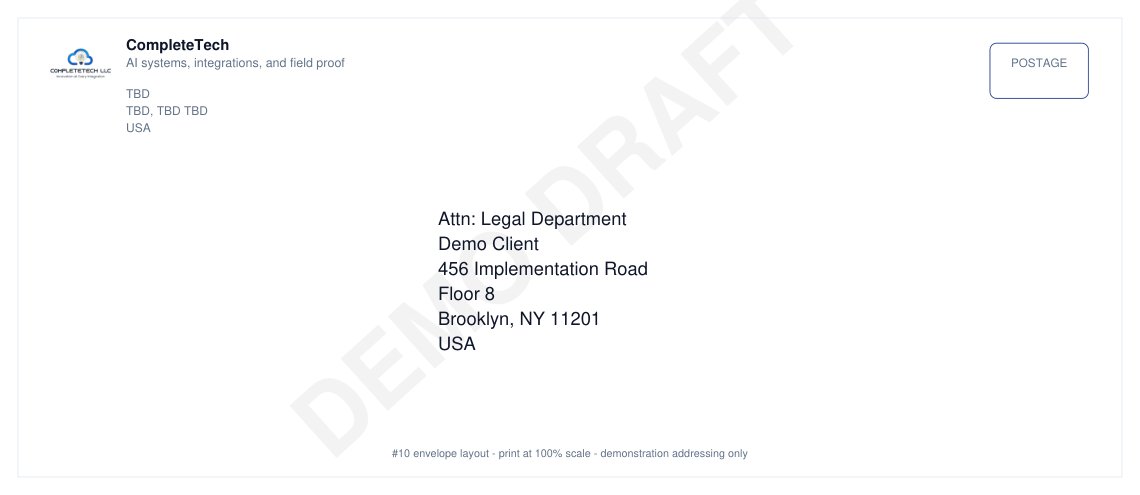

**certificate_page-1.png**

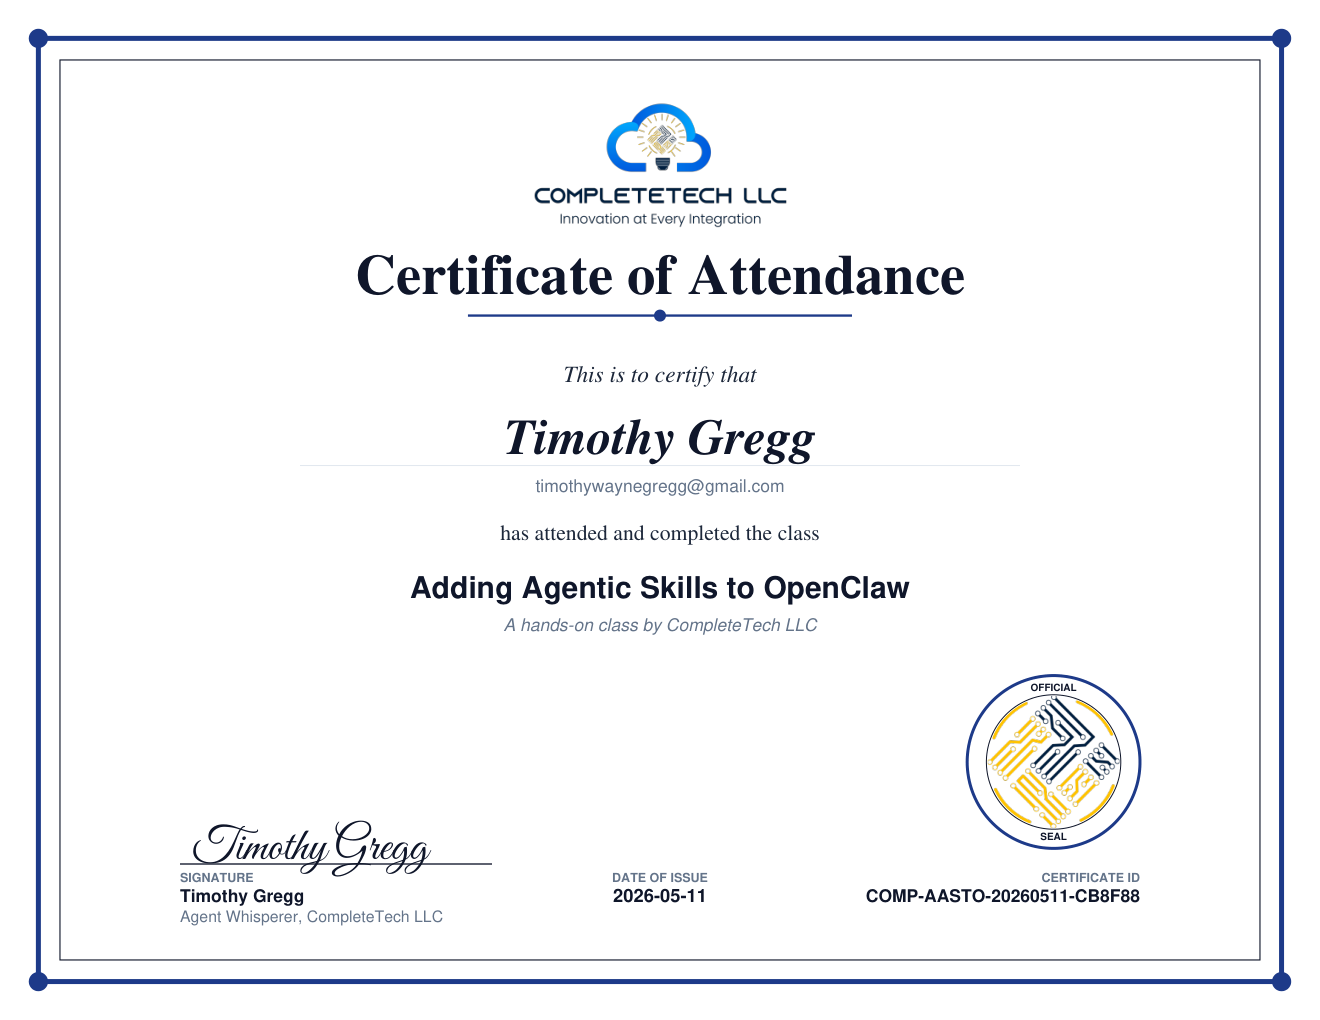

In [2]:
for name in ["contract_page-1.png", "envelope_page-1.png", "certificate_page-1.png"]:
    p = PREVIEW_DIR / name
    if p.exists():
        display(Markdown(f"**{name}**"))
        display(Image(filename=str(p), width=520))
    else:
        display(Markdown(f"_No preview yet for `{name}` — we'll generate it below._"))


---
## Step 1 — Understand the Pipeline

One config, two generators, three outputs:

```
config.ini ──┬──► generate_contract.py     ──► contract.pdf
             │                              └─► envelope.pdf
             └──► generate_certificate.py  ───► certificate.pdf
```

Every section of `config.ini` maps to a real-world business detail. The generators just fill in the blanks against a Jinja2 template (contract) or a layout script (certificate). Let's see the sections that drive everything:

In [3]:
import configparser

cfg = configparser.ConfigParser(interpolation=None)
cfg.read("config.ini", encoding="utf-8")

for section in cfg.sections():
    keys = ", ".join(cfg[section].keys())
    print(f"[{section}]\n  {keys}\n")


[provider]
  legal_name, trade_name, entity_type, state_of_formation, address_line1, address_line2, city, state, postal_code, country, email, phone, website, signatory_name, signatory_title

[client]
  legal_name, trade_name, entity_type, state_of_formation, address_line1, address_line2, city, state, postal_code, country, email, phone, website, signatory_name, signatory_title

[agreement]
  title, contract_id, agreement_date, effective_date, term, governing_law, venue, services_summary, project_name, fee_type, fee_amount, deposit, payment_terms, revision_rounds, delivery_schedule, acceptance_period_days, support_period_days, warranty_days

[agentic_development]
  system_description, autonomy_level, human_in_loop, model_or_stack, deployment_environment, evaluation_plan, monitoring_plan, excluded_uses

[confidentiality_data]
  client_data, provider_data, privacy_terms, retention_period_days, backup_policy

[ip]
  pre_existing_ip, work_product_owner, license_back, open_source_policy

[ris

> **What just happened:** we read the same INI file the generators will. `[provider]` and `[branding]` are shared across all artifacts; `[client]` and `[agreement]` drive the contract; `[envelope]` adds mailing details; `[certificate]` powers the certificate.

---
## Step 2 — Configure Your Brand

The `[branding]` block decides the visual identity for every artifact: logo, monogram, accent colors, watermark, and signatory title. Change one value here and all three PDFs update on the next run.

Note: the certificate uses `signatory_title = Agent Whisperer, CompleteTech LLC`, while contracts use `signatory_title = Founder`. Pick the right title per artifact type.

Primary logo (used on contract letterhead + certificate header):


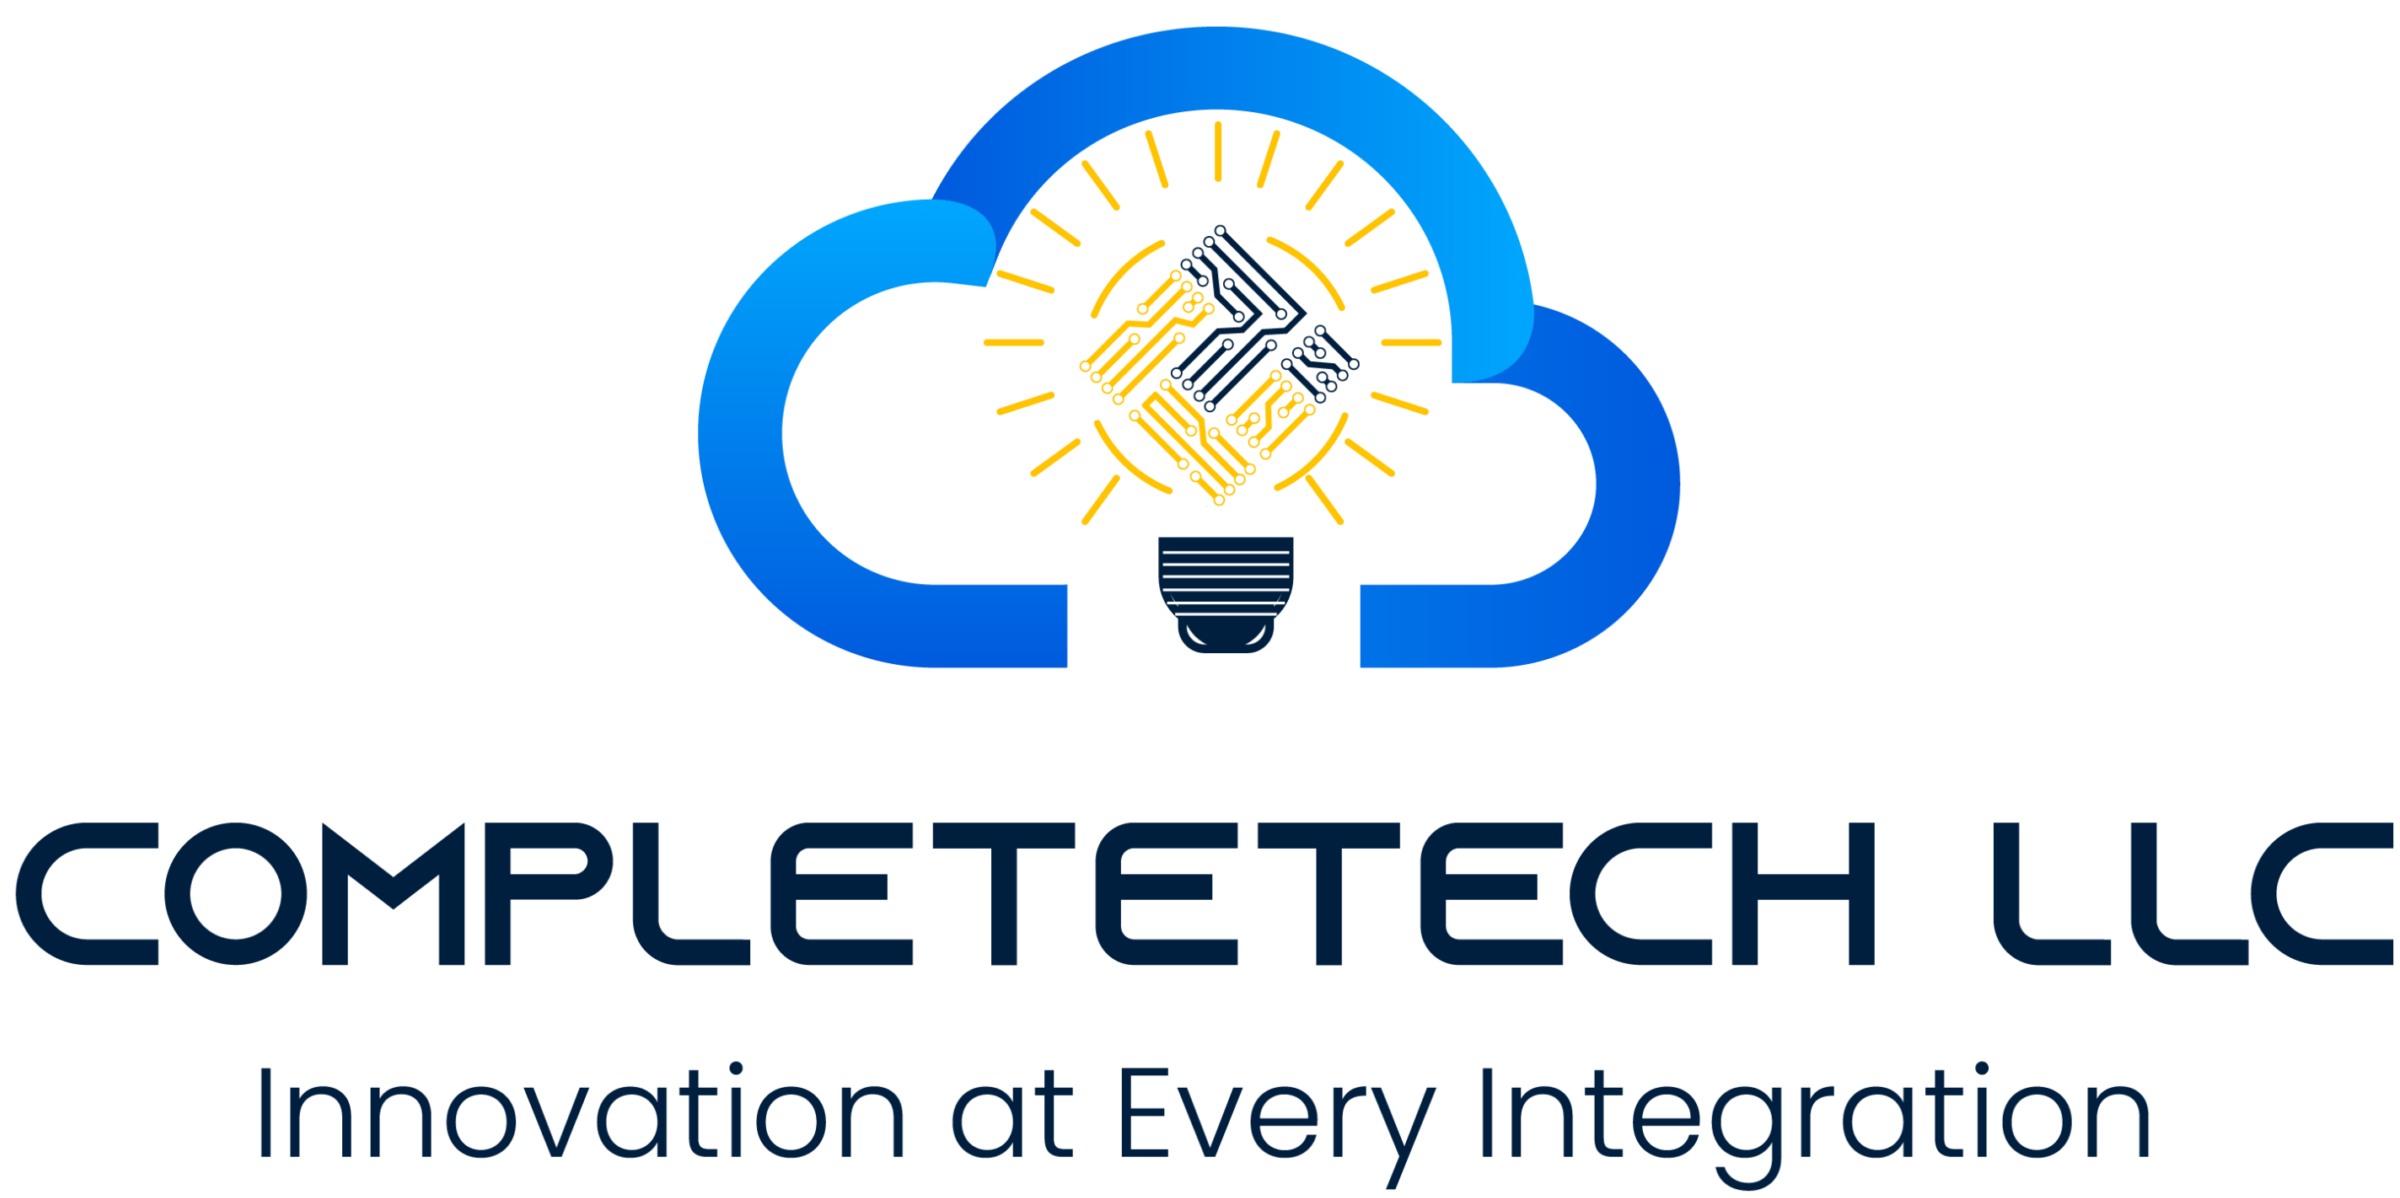


CT-circuit stamp (used as the certificate's official seal):


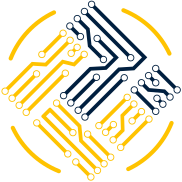

In [4]:
print("Primary logo (used on contract letterhead + certificate header):")
display(Image(filename="assets/logo.png", width=320))

print("\nCT-circuit stamp (used as the certificate's official seal):")
display(Image(filename="assets/stamp_ct.png", width=160))


In [5]:
branding = cfg["branding"]
swatches = {
    "accent":      branding.get("accent_color", "#1E3A8A"),
    "accent_dark": branding.get("accent_color_dark", "#0F172A"),
    "accent_soft": branding.get("accent_color_soft", "#EEF2FF"),
    "muted":       branding.get("muted_color", "#64748B"),
}

html = '<div style="display:flex;gap:12px;font-family:sans-serif">' + "".join(
    f'<div style="text-align:center">'
    f'<div style="width:90px;height:90px;background:{hexv};border:1px solid #ccc;border-radius:6px"></div>'
    f'<div style="font-size:11px;margin-top:4px"><b>{name}</b><br>{hexv}</div></div>'
    for name, hexv in swatches.items()
) + '</div>'
display(Markdown(html))


<div style="display:flex;gap:12px;font-family:sans-serif"><div style="text-align:center"><div style="width:90px;height:90px;background:#1E3A8A;border:1px solid #ccc;border-radius:6px"></div><div style="font-size:11px;margin-top:4px"><b>accent</b><br>#1E3A8A</div></div><div style="text-align:center"><div style="width:90px;height:90px;background:#0F172A;border:1px solid #ccc;border-radius:6px"></div><div style="font-size:11px;margin-top:4px"><b>accent_dark</b><br>#0F172A</div></div><div style="text-align:center"><div style="width:90px;height:90px;background:#EEF2FF;border:1px solid #ccc;border-radius:6px"></div><div style="font-size:11px;margin-top:4px"><b>accent_soft</b><br>#EEF2FF</div></div><div style="text-align:center"><div style="width:90px;height:90px;background:#64748B;border:1px solid #ccc;border-radius:6px"></div><div style="font-size:11px;margin-top:4px"><b>muted</b><br>#64748B</div></div></div>

> **Try this:** edit `accent_color` in `config.ini` and re-run Step 3. Every accent ring, rule, and seal border picks up the new color automatically.

---
## Step 3 — Generate the Contract

The contract is rendered from `templates/agentic_development_agreement.md.j2` — a Jinja2 Markdown template — and compiled to a multi-page PDF with cover page, letterhead band, watermark, footer, and signature block.

We'll run with `--no-envelope` so this step produces **only** the contract; we'll cover the envelope in Step 4.

In [6]:
run("python", "generate_contract.py",
    "--config", "config.ini",
    "--out", "output/notebook_contract.pdf",
    "--no-envelope")


$ python generate_contract.py --config config.ini --out output/notebook_contract.pdf --no-envelope


Contract PDF: C:\Users\timot\Documents\projects\agentic_contract_skill\output\notebook_contract.pdf
Filled Markdown: C:\Users\timot\Documents\projects\agentic_contract_skill\output\notebook_contract.md


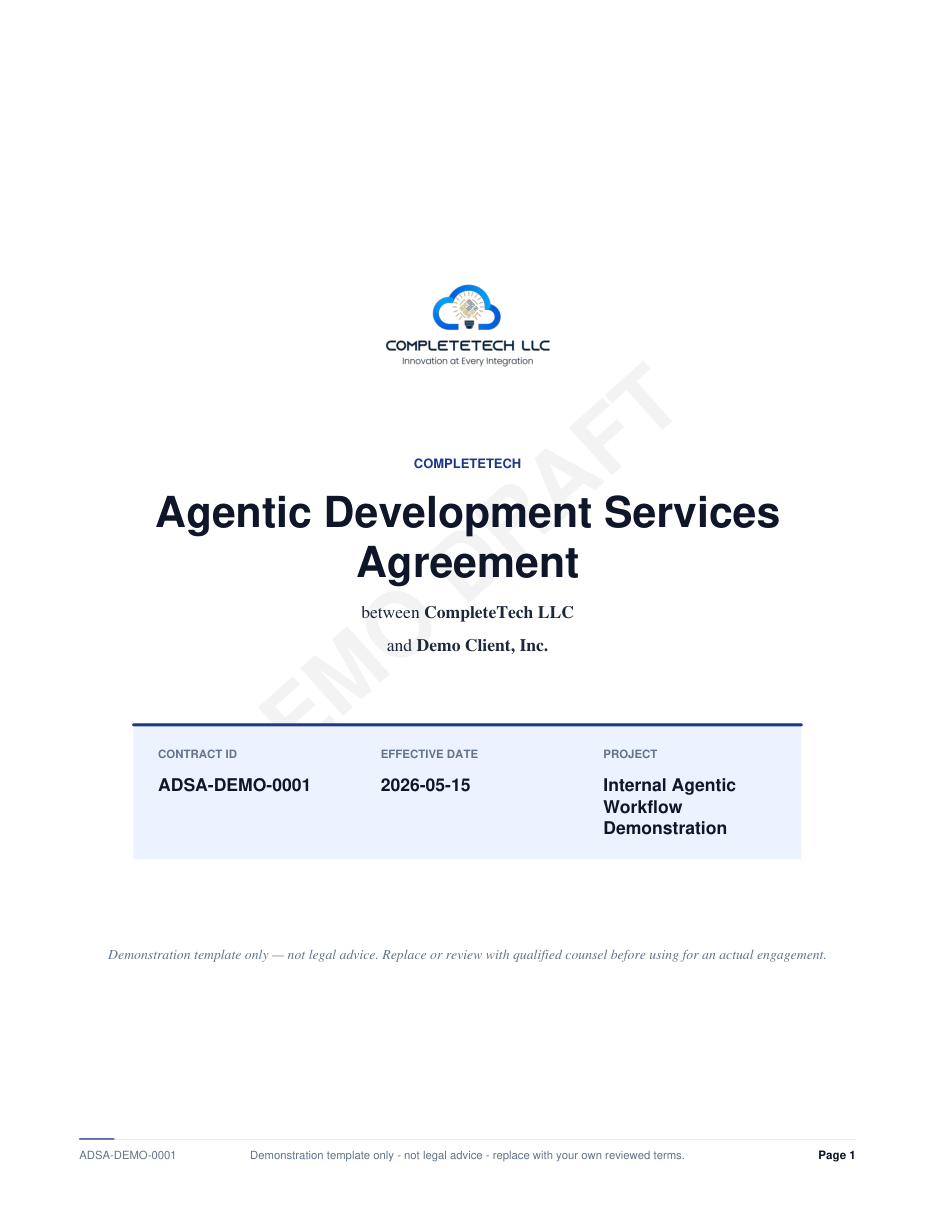

In [7]:
show_pdf("output/notebook_contract.pdf", page=0)  # cover page


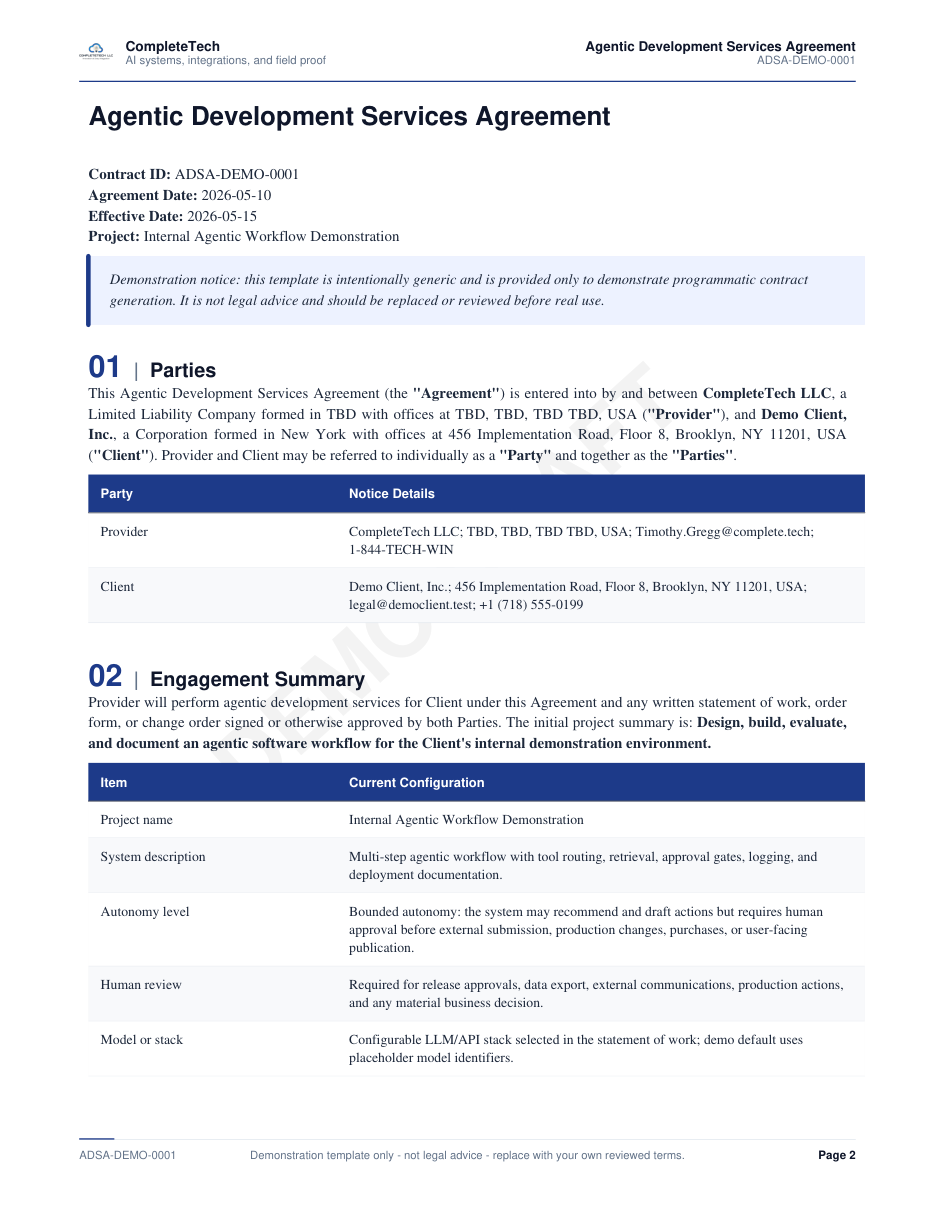

In [8]:
show_pdf("output/notebook_contract.pdf", page=1)  # first content page with letterhead band


> **What just happened:** Jinja2 substituted every `{{ provider.legal_name }}`-style placeholder with values from `config.ini`, the resulting Markdown was converted to ReportLab flowables, and the page-furniture callbacks drew the letterhead band, watermark, and footer.

**Extension:** stack INIs to customize the contract per real client — `python generate_contract.py --config config.ini examples/minimum_client_override.ini --out output/acme_contract.pdf`.

---
## Step 4 — Generate the Addressed Envelope

The envelope is its own **#10-sized** PDF (9.5" × 4.125"), with the return address pulled from `[provider]` and the recipient block from `[client]`. Printers typically handle envelopes on a separate tray, so it's a separate file by design.

Re-running the contract generator (without `--no-envelope`) produces both PDFs — we point `--envelope-out` at a notebook-specific filename so we don't collide with the existing demo output.

In [9]:
run("python", "generate_contract.py",
    "--config", "config.ini",
    "--out", "output/notebook_contract.pdf",
    "--envelope-out", "output/notebook_envelope.pdf")


$ python generate_contract.py --config config.ini --out output/notebook_contract.pdf --envelope-out output/notebook_envelope.pdf


Envelope PDF: C:\Users\timot\Documents\projects\agentic_contract_skill\output\notebook_envelope.pdf
Contract PDF: C:\Users\timot\Documents\projects\agentic_contract_skill\output\notebook_contract.pdf
Filled Markdown: C:\Users\timot\Documents\projects\agentic_contract_skill\output\notebook_contract.md


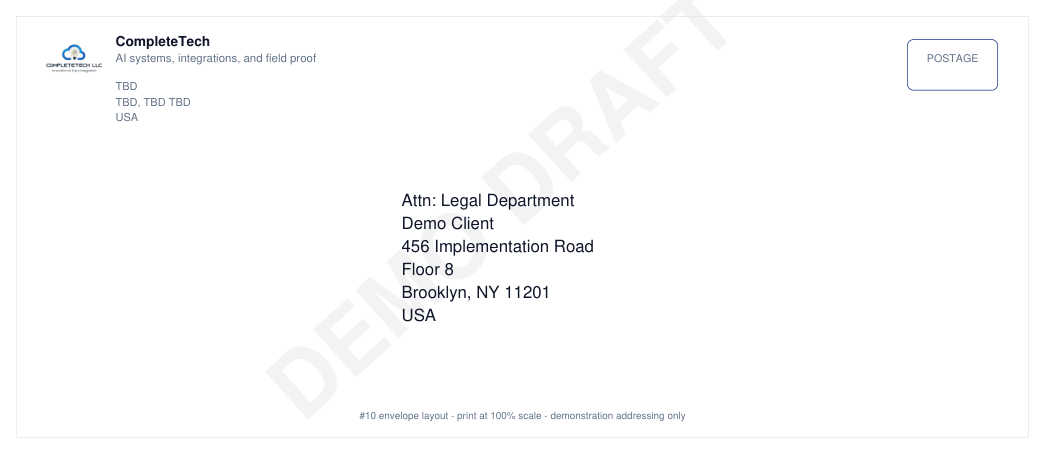

In [10]:
show_pdf("output/notebook_envelope.pdf", page=0)


> **What just happened:** the same `generate_contract.py` ran end-to-end, but this time the envelope sub-routine fired and wrote a second PDF. The return address strips the company name (it's already in the logo banner), the recipient block prepends `recipient_attention` from `[envelope]`, and the watermark mirrors the contract for consistency.

**Try this:** set `envelope_enabled = no` under `[branding]` to skip envelope creation entirely — useful for clients who don't need a mailed contract.

---
## Step 5 — Generate a Course Certificate (with Auto-Fill)

Certificates use a different generator, but the same brand. Two fields auto-fill so you don't have to think about them:

| Field | Auto behavior when blank in config |
|---|---|
| `issue_date` | Today's date (`date.today().isoformat()`). |
| `certificate_id` | Deterministic `COMP-{course-prefix}-{YYYYMMDD}-{sha1[:6]}`. Same recipient on same day = same ID. |

The official seal uses the **CT-circuit mark** (the element from inside the lightbulb in the main logo), clipped into a circular badge. The signature uses **Great Vibes** (Google Fonts, SIL OFL) for a hand-signed look.

Edit the two lines below to certify whoever you like — that's the entire per-attendee workload.

In [11]:
recipient_name  = "Jane Q. Attendee"     # ← edit
recipient_email = "jane@example.com"     # ← edit

run("python", "generate_certificate.py",
    "--recipient-name", recipient_name,
    "--recipient-email", recipient_email)


$ python generate_certificate.py --recipient-name Jane Q. Attendee --recipient-email jane@example.com


Certificate PDF: C:\Users\timot\Documents\projects\agentic_contract_skill\output\certificate_jane_q_attendee.pdf


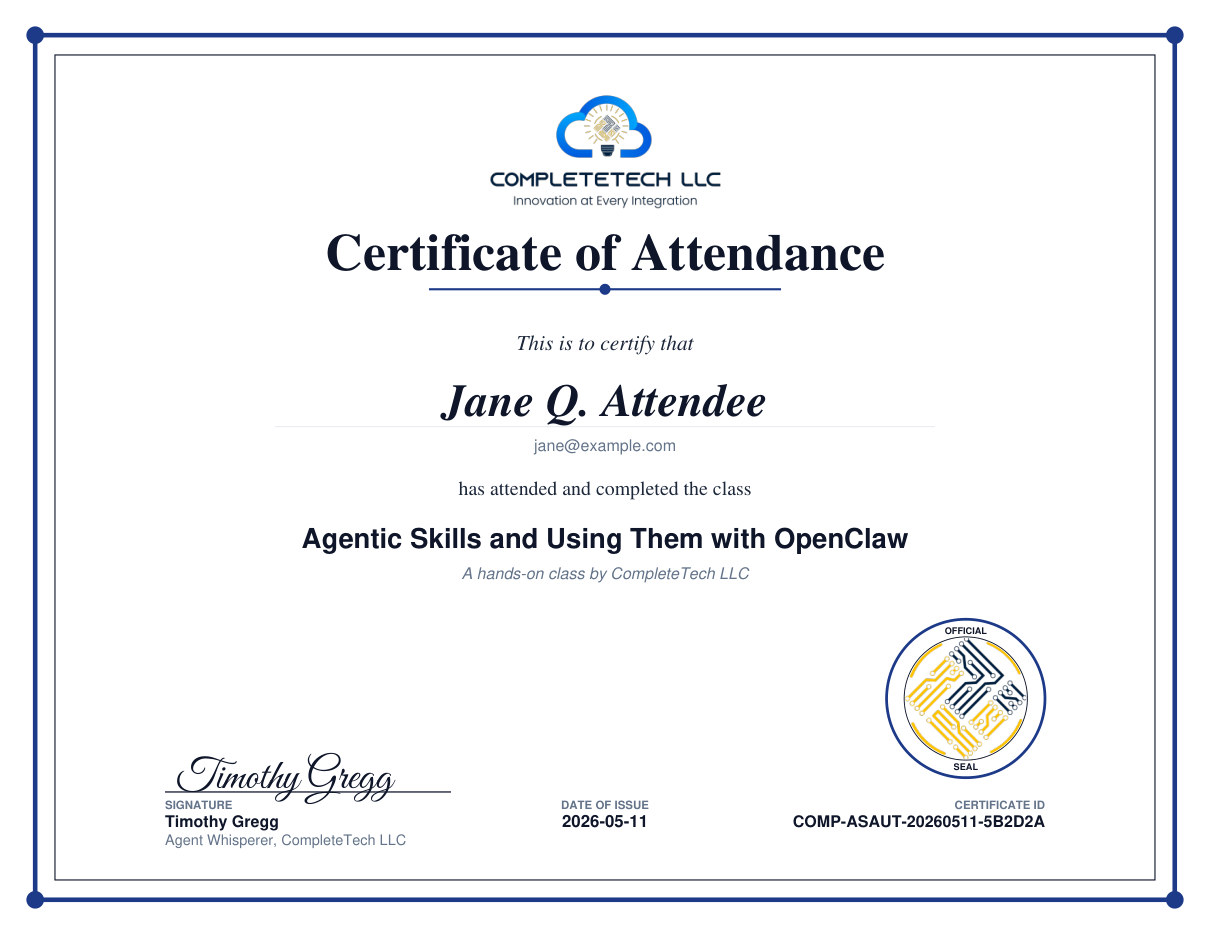

In [12]:
import re
slug = re.sub(r"[^A-Za-z0-9]+", "_", recipient_name).strip("_").lower()
cert_path = f"output/certificate_{slug}.pdf"
show_pdf(cert_path)


> **What just happened:** the generator pulled course title, signatory, and branding from `config.ini`, computed today's date and a SHA-1-based ID, registered the Great Vibes font, drew the certificate, and clipped the CT-circuit stamp inside the official-seal ring.

Idempotence note: re-running with the same recipient on the same day gives you a byte-identical certificate ID — handy for re-issuing without surprises.

---
## Step 6 — Customize, Re-Run, Extend

Three patterns for taking this beyond the demo. Pick whichever fits your workflow — they're not mutually exclusive.

### Pattern 1 — Per-client contract overrides

Stack INIs; later files win. Keep your base brand in `config.ini` and write a tiny override per client:

```bash
python generate_contract.py \
  --config config.ini examples/minimum_client_override.ini \
  --out output/acme_contract.pdf \
  --envelope-out output/acme_envelope.pdf
```

### Pattern 2 — Per-attendee certificate runs

Re-run the Step 5 cell with different `recipient_name` / `recipient_email` values. Each run lands at `output/certificate_<slug>.pdf` so you accumulate one file per attendee. Below, we re-issue for a second person to prove the pattern:

$ python generate_certificate.py --recipient-name Alex Sample --recipient-email alex@example.com


Certificate PDF: C:\Users\timot\Documents\projects\agentic_contract_skill\output\certificate_alex_sample.pdf


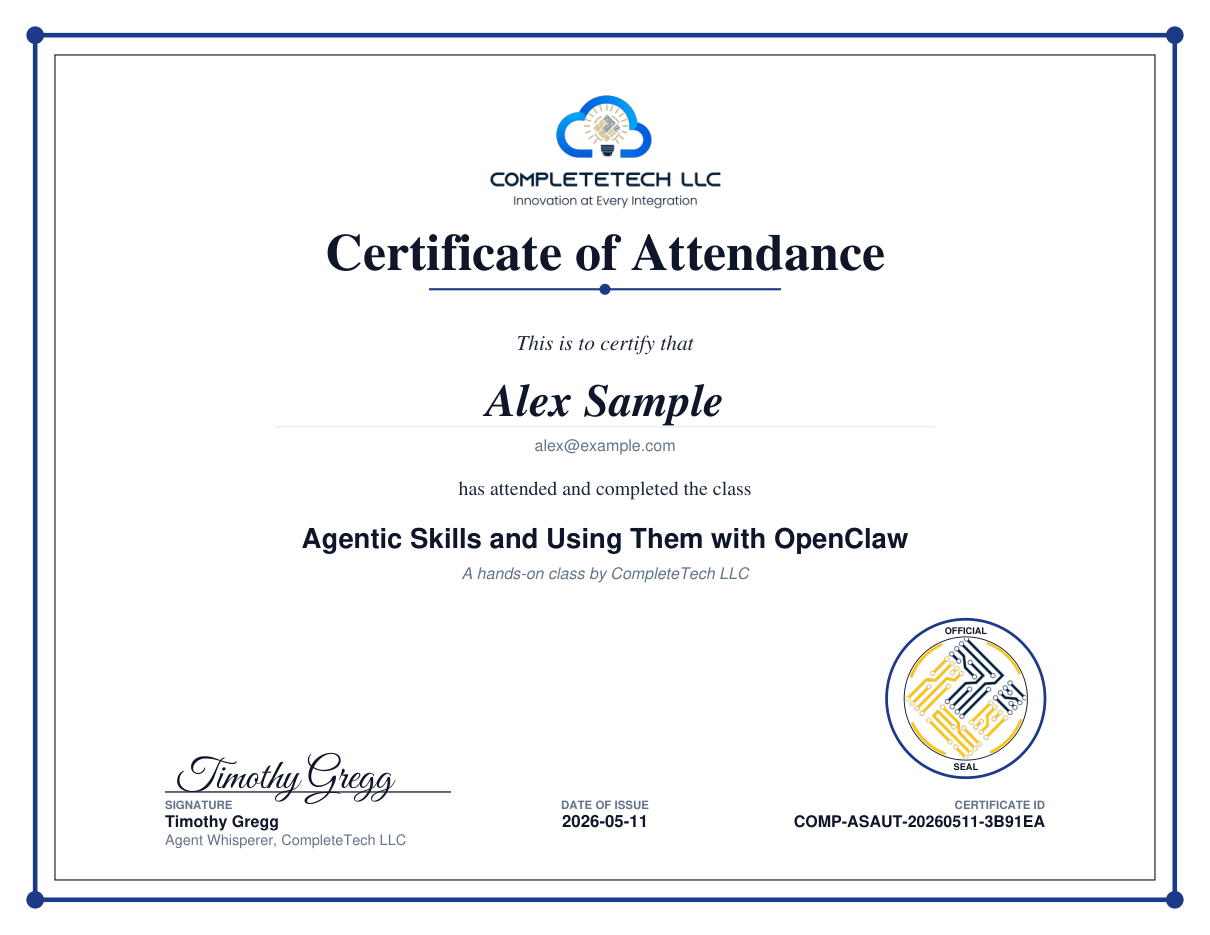

In [13]:
recipient_name  = "Alex Sample"        # ← change me for each attendee
recipient_email = "alex@example.com"

run("python", "generate_certificate.py",
    "--recipient-name", recipient_name,
    "--recipient-email", recipient_email)

slug = re.sub(r"[^A-Za-z0-9]+", "_", recipient_name).strip("_").lower()
show_pdf(f"output/certificate_{slug}.pdf")


### Pattern 3 — Agent integration

An agent skill invokes either generator the same way you just did. A minimal skill action looks like:

```python
import subprocess

def issue_certificate(name: str, email: str) -> str:
    subprocess.run(
        ["python", "generate_certificate.py",
         "--recipient-name", name, "--recipient-email", email],
        check=True,
    )
    slug = "".join(c if c.isalnum() else "_" for c in name).strip("_").lower()
    return f"output/certificate_{slug}.pdf"
```

See `SKILL.md` → *Agent Operating Guidance* for the full agent-side contract.

---
## Where to take this next

- **Swap the contract template** — `templates/agentic_development_agreement.md.j2` is plain Jinja2 + Markdown. Drop in your own clauses, add jurisdiction-specific language, or fork the file per practice area.
- **Add new artifact types** — invoice, NDA, statement of work — by mirroring `generate_certificate.py` and adding a new `[section]` to `config.ini`.
- **Wire into a CRM** — pull recipient/client rows from your CRM, loop the Step 5/Pattern 2 cell.
- **Schedule it** — use the project's cron/scheduling skill to issue monthly retainer contracts or end-of-class certificates automatically.

Demonstration disclaimer: the contract template is illustrative, not legal advice — replace with your counsel-reviewed terms before any real engagement.